In [1]:
import torch 
from torch import nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = 'mps' if torch.mps.is_available() else 'cpu'
torch.mps.manual_seed(1234)
torch.manual_seed(1234)

In [2]:
from sklearn.datasets import make_circles
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [3]:
import pandas as pd
circles = pd.DataFrame(
    {
        "X1": X[:, 0], "X2": X[:, 1], "label": y
    }
)

In [4]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

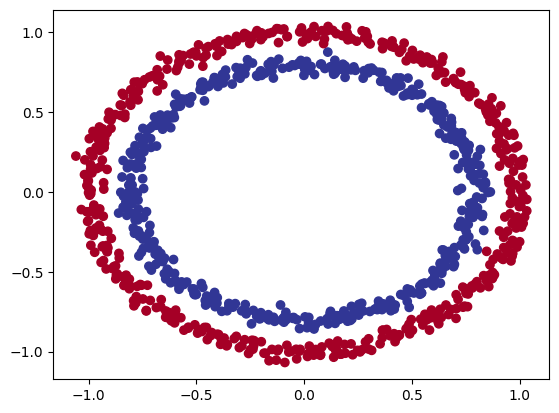

In [5]:
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)


In [8]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

### Creating some models

In [10]:
class CircleModel0(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
    
    def forward(self, X):
        return self.layer_2(self.layer_1(X))

model0 = CircleModel0().to(device=device)
model0

CircleModel0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [11]:
loss_fun = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.1)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

In [12]:
# 2. Move ALL the data once, before the loop ever starts
X_train = X_train.to(device)
y_train = y_train.reshape(-1, 1).to(device)
X_test = X_test.to(device)
y_test = y_test.reshape(-1, 1).to(device)

In [13]:
train_losses, test_losses, epochs = [], [], []
total_epochs = 200
for i in range(total_epochs):
    model0.train()
    train_logits = model0(X_train)
    train_loss = loss_fun(train_logits, y_train)
    train_pred = torch.round(torch.sigmoid(train_logits))

    train_accuracy = accuracy_fn(y_train, train_pred)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    with torch.inference_mode():
        model0.eval()
        test_logits = model0(X_test)
        test_loss = loss_fun(test_logits, y_test)

        test_pred = torch.round(torch.sigmoid(test_logits))
        test_accuracy = accuracy_fn(y_test, test_pred)
        test_losses.append(test_loss.item())
        train_losses.append(train_loss.item())
        epochs.append(i)
        if i % 10 == 0:
            print(f'Epoch: {i} | Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}|Train Loss: {train_loss} | Test loss: {test_loss}')

Epoch: 0 | Accuracy: 51.625 | Test Accuracy: 49.5|Train Loss: 0.6932223439216614 | Test loss: 0.6945013403892517
Epoch: 10 | Accuracy: 51.625 | Test Accuracy: 48.5|Train Loss: 0.6931814551353455 | Test loss: 0.6944555640220642
Epoch: 20 | Accuracy: 51.74999999999999 | Test Accuracy: 48.5|Train Loss: 0.6931501626968384 | Test loss: 0.694415807723999
Epoch: 30 | Accuracy: 51.5 | Test Accuracy: 48.0|Train Loss: 0.6931250095367432 | Test loss: 0.6943815350532532
Epoch: 40 | Accuracy: 51.87500000000001 | Test Accuracy: 47.0|Train Loss: 0.6931043267250061 | Test loss: 0.6943526864051819
Epoch: 50 | Accuracy: 51.87500000000001 | Test Accuracy: 47.5|Train Loss: 0.6930871605873108 | Test loss: 0.6943289637565613
Epoch: 60 | Accuracy: 51.74999999999999 | Test Accuracy: 47.5|Train Loss: 0.6930726766586304 | Test loss: 0.6943098306655884
Epoch: 70 | Accuracy: 51.37500000000001 | Test Accuracy: 48.0|Train Loss: 0.693060576915741 | Test loss: 0.6942948698997498
Epoch: 80 | Accuracy: 51.2499999999999

In [14]:
import numpy as np
def plot_decision_boundary(model, X, y):
    # 1. Move everything to CPU for plotting (Matplotlib doesn't speak GPU/MPS)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # 2. Setup a meshgrid to cover the entire plot area
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # 3. Create the grid points and get model predictions
    # We flatten the grid, turn it into a tensor, and run it through the model
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()
    
    model.eval()
    with torch.inference_mode():
        logits = model(X_to_pred_on)
        # Apply the 3-step pipeline to get 0 or 1
        y_pred = torch.round(torch.sigmoid(logits))

    # 4. Reshape predictions back into the grid shape for plotting
    y_pred = y_pred.reshape(xx.shape).detach().numpy()

    # 5. Plot the decision boundary "contours" and the original data
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Model Decision Boundary")
    plt.show()
    
    # 6. Move model back to device if you plan to keep training
    model.to(device)

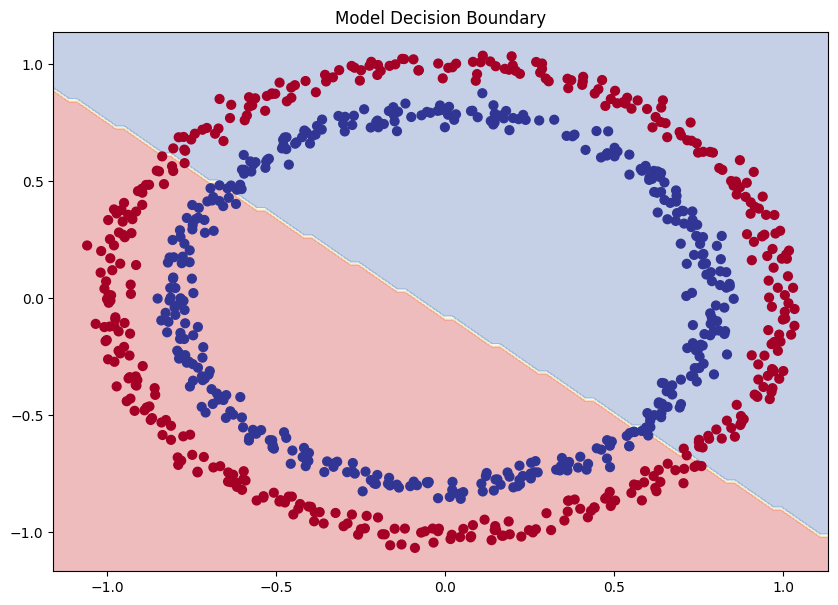

In [15]:
plot_decision_boundary(model0, X_train, y_train)

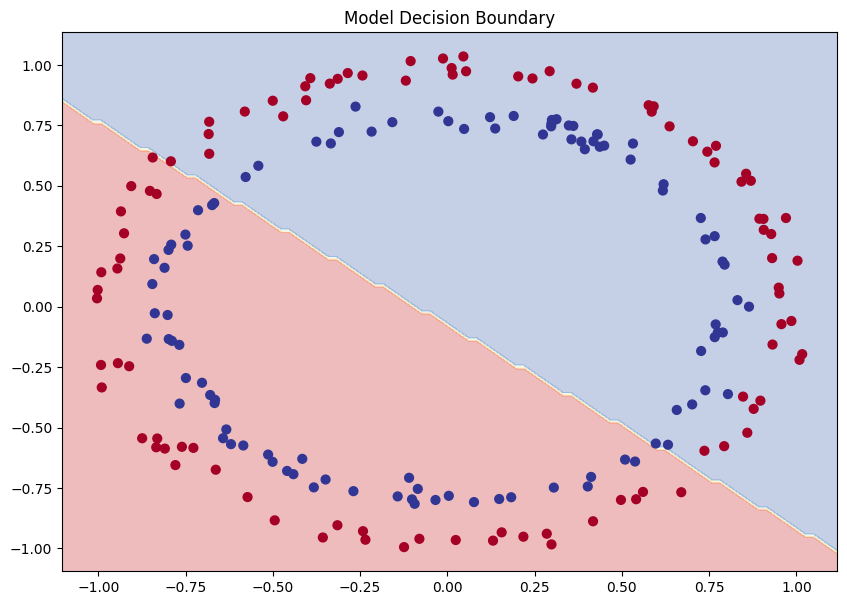

In [16]:
plot_decision_boundary(model0, X_test, y_test)

In [17]:
class CircleModel2(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    
    def forward(self, X):
        return self.layer_3(self.relu(self.layer_2(self.layer_1(X))))

model2 = CircleModel2().to(device=device)
model2


loss_fun = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model2.parameters(), lr=0.1)

In [18]:
train_losses, test_losses, epochs = [], [], []
total_epochs = 1000
for i in range(total_epochs):
    model2.train()
    train_logits = model2(X_train)
    train_loss = loss_fun(train_logits, y_train)
    train_pred = torch.round(torch.sigmoid(train_logits))

    train_accuracy = accuracy_fn(y_train, train_pred)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    with torch.inference_mode():
        model2.eval()
        test_logits = model2(X_test)
        test_loss = loss_fun(test_logits, y_test)

        test_pred = torch.round(torch.sigmoid(test_logits))
        test_accuracy = accuracy_fn(y_test, test_pred)
        test_losses.append(test_loss.item())
        train_losses.append(train_loss.item())
        epochs.append(i)
        if i % 10 == 0:
            print(f'Epoch: {i} | Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}|Train Loss: {train_loss} | Test loss: {test_loss}')

Epoch: 0 | Accuracy: 50.0 | Test Accuracy: 50.0|Train Loss: 0.6944239139556885 | Test loss: 0.6956106424331665
Epoch: 10 | Accuracy: 50.0 | Test Accuracy: 50.0|Train Loss: 0.6914142966270447 | Test loss: 0.6931626796722412
Epoch: 20 | Accuracy: 50.0 | Test Accuracy: 50.0|Train Loss: 0.6900642514228821 | Test loss: 0.6922124624252319
Epoch: 30 | Accuracy: 50.0 | Test Accuracy: 50.0|Train Loss: 0.6893717646598816 | Test loss: 0.6918179392814636
Epoch: 40 | Accuracy: 51.125 | Test Accuracy: 51.0|Train Loss: 0.6889469623565674 | Test loss: 0.6916431784629822
Epoch: 50 | Accuracy: 53.75 | Test Accuracy: 50.0|Train Loss: 0.6886183023452759 | Test loss: 0.6915411353111267
Epoch: 60 | Accuracy: 60.25 | Test Accuracy: 51.5|Train Loss: 0.6883285641670227 | Test loss: 0.6914666891098022
Epoch: 70 | Accuracy: 54.625 | Test Accuracy: 49.0|Train Loss: 0.6880596876144409 | Test loss: 0.6914024353027344
Epoch: 80 | Accuracy: 54.50000000000001 | Test Accuracy: 49.5|Train Loss: 0.6877961754798889 | Test

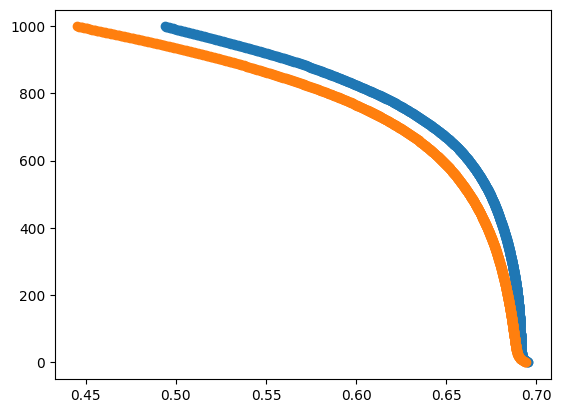

In [19]:
plt.scatter(test_losses, epochs)
plt.scatter(train_losses, epochs)
plt.show()

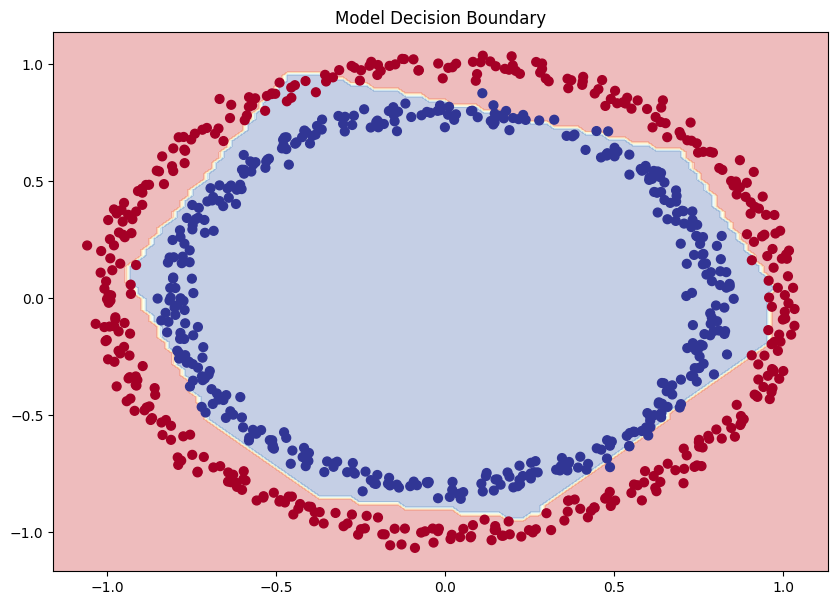

In [20]:
plot_decision_boundary(model2, X_train, y_train)

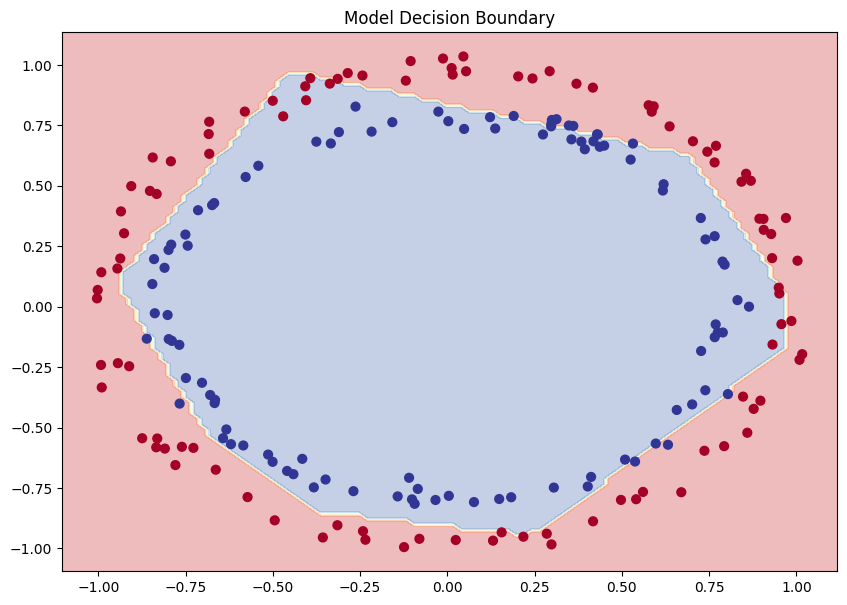

In [21]:
plot_decision_boundary(model2, X_test, y_test)

### Creating some non-linear activations by hand

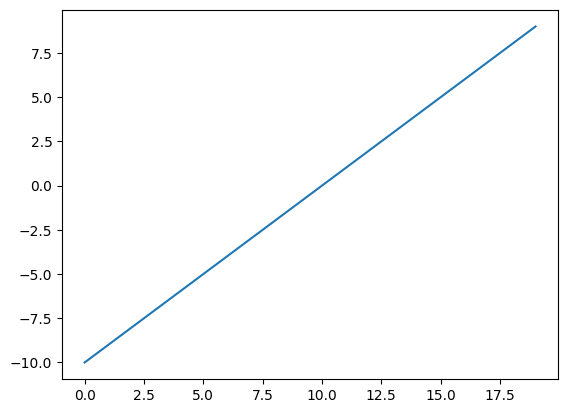

In [22]:
x = torch.arange(-10, 10, 1, dtype=torch.float)
plt.plot(x)

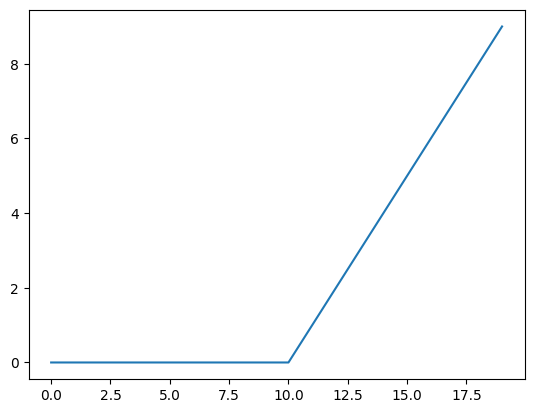

In [23]:
def relu(x):
    return torch.maximum(torch.tensor(0), x)

relu_x = relu(x)
plt.plot(relu_x)

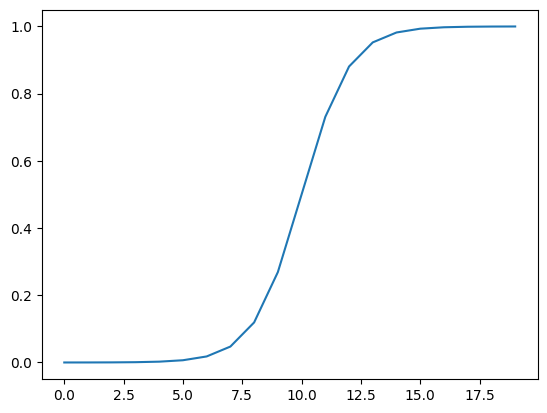

In [24]:
def sigmoid(x):
    return 1/ (1 + torch.exp(-x))

sig_x = sigmoid(x)
plt.plot(sig_x)